# Разработка A/B-тестирования и анализ результатов

Тех. Задание: Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

- Автор: Агансонов Руслан
- Дата: 24.02

## Описание данных

Мы будем работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Мои задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработаем с историческими данными приложения:

- Импортируем библиотеку pandas.

- Считаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведем на экран первые пять строк полученного датафрейма.

In [1]:
# Импортируем библиотеки
import pandas as pd
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil

In [2]:
# Выгружаем данные
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

In [3]:
# Выводим первые строки датафрейма на экран
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
amount_of_sessions = sessions_history.groupby('user_id').agg({'session_id': 'nunique'}).reset_index()
max_amount = amount_of_sessions.sort_values(by='session_id', ascending=False).iloc[0]['user_id']
sessions_history[sessions_history['user_id'] == max_amount]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


Выбранный пользователь демонстрирует высокую вовлеченность, совершив 10 последовательных сессий в течение 12 дней с момента установки приложения на Android. Данные подтверждают корректную структуру логов: технические параметры и дата установки остаются неизменными, в то время как номер сессии и сессионные метки обновляются хронологически.

#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, нам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считаем, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразим их на одном графике.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.


In [5]:
sessions_filter = sessions_history.drop_duplicates(subset=['user_id', 'session_date'])
users_per_day = sessions_filter.groupby('session_date').agg({'user_id': 'nunique', 'registration_flag': 'sum'})
users_per_day

,user_id,registration_flag
session_date,,
2025-08-11,3919,169
2025-08-12,6056,336
2025-08-13,8489,464
2025-08-14,10321,625
2025-08-15,14065,840
2025-08-16,12205,916
2025-08-17,11200,833
2025-08-18,10839,860
2025-08-19,12118,831


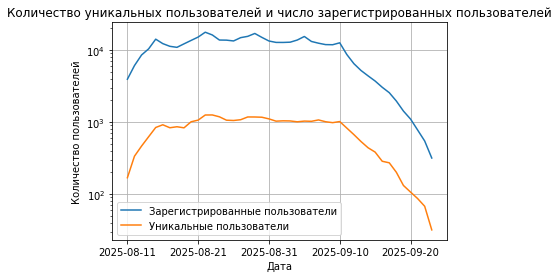

In [6]:
users_per_day.plot()
plt.yscale('log')
plt.title('Количество уникальных пользователей и число зарегистрированных пользователей')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid()
plt.legend(labels=['Зарегистрированные пользователи', 'Уникальные пользователи'])
plt.show()

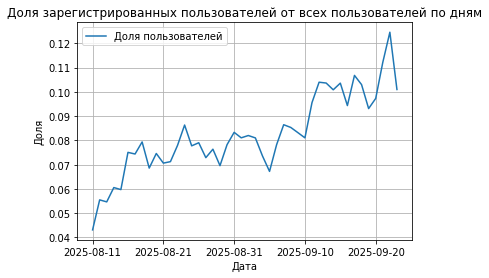

In [7]:
ax = (users_per_day['registration_flag'] / users_per_day['user_id']).plot(kind='line')
plt.title('Доля зарегистрированных пользователей от всех пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.grid()
plt.legend(labels=['Доля пользователей'])
plt.show()

Несмотря на резкое снижение общего трафика после 10 сентября, доля зарегистрированных пользователей демонстрирует стабильный рост, увеличившись с 4% до 12% к концу периода. Это может свидетельствовать о том, что приложение покидают преимущественно неавторизованные пользователи, в то время как лояльное ядро аудитории остается активным.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц. Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

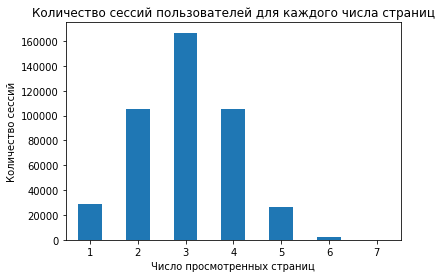

In [8]:
sessions_history.groupby('page_counter')['session_id'].count().plot(kind='bar', rot=0)
plt.title('Количество сессий пользователей для каждого числа страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.show()

Распределение сессий пользователей для каждого числа страниц напоминает нормальное с пиком в 3 просмотренных страницах.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [9]:
sessions_history['good_session'] = sessions_history['page_counter'] >= 4

In [10]:
# Сортируем данные по времени сессии для каждого пользователя
sessions_history_sorted = sessions_history.sort_values(['user_id', 'session_start_ts'])

# Выделяем первую сессию для каждого пользователя
first_sessions = sessions_history_sorted.groupby('user_id').first().reset_index()

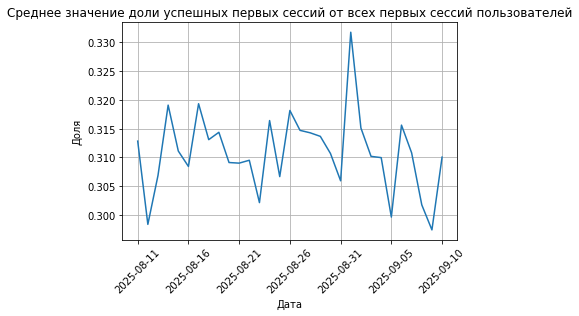

In [11]:
first_sessions.groupby('session_date')['good_session'].mean().plot(kind='line', rot = 45)
plt.title('Cреднее значение доли успешных первых сессий от всех первых сессий пользователей')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.grid()

Доля успешных первых сессий демонстрирует стабильность на протяжении всего месяца, удерживаясь в узком диапазоне 30–33%. Это говорит о том, что качество контента и работы алгоритмов рекомендаций для новых пользователей остается предсказуемым и не подвержено резким колебаниям.

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки

Установим для тестирования данные занчения:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.


In [12]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.3*0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [13]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()
# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(2*int(sample_size)/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведите на экран процентную разницу в количестве пользователей в группах A и B. Построим любую удобную визуализацию, на которой будет видно возможное различие двух групп.

In [14]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

In [15]:
x = sessions_test_part.groupby(['session_date', 'test_group'])['user_id'].nunique().reset_index()
x.columns = ['session_date', 'test_group', 'count_users']
x

,session_date,test_group,count_users
0,2025-10-14,A,1477
1,2025-10-14,B,1466


In [16]:
delta = 100 * abs(x.iloc[0]['count_users'] - x.iloc[1]['count_users']) / x.iloc[0]['count_users']
delta

0.7447528774542993

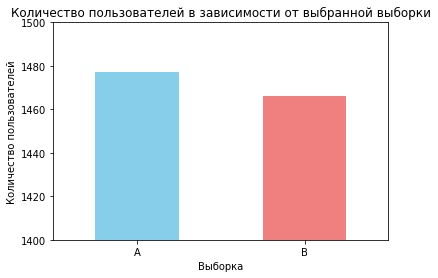

In [17]:
ax = x.set_index('test_group').plot(kind='bar', rot=0, legend=False)
plt.ylim(1400, 1500)

#Задаём цвет каждому столбцу по отдельности
for i, patch in enumerate(ax.patches):
    if i == 0:
        patch.set_facecolor('skyblue')  #для первого столбца (категория 'A')
    elif i == 1:
        patch.set_facecolor('lightcoral')  #для второго столбца (категория 'B')
plt.title('Количество пользователей в зависимости от выбранной выборки')
plt.xlabel('Выборка')
plt.ylabel('Количество пользователей')
plt.show()

Разница в количестве пользователей между группами A и B составляет менее 1%, что свидетельствует о качественном сплитовании трафика

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [18]:
#Проведем с помощью множеств проверку на пересечение пользователей в 2 группах
len(set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']) \
    & set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']))

0

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.


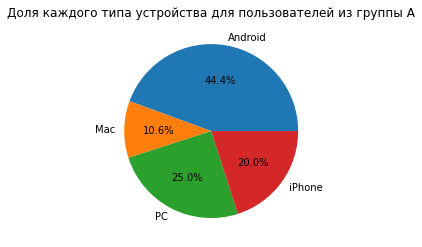

In [19]:
sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device')['user_id'].nunique().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    ylabel=''
)
plt.title('Доля каждого типа устройства для пользователей из группы A')
plt.show()

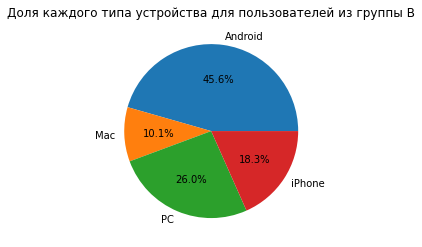

In [20]:
sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device')['user_id'].nunique().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    ylabel=''
)
plt.title('Доля каждого типа устройства для пользователей из группы B')
plt.show()

Распределение устройств в группах A и B практически идентично: в обоих случаях лидирует Android (45%), а наименьшую долю занимает Mac (~10%).
Минимальные различия в долях (не превышающие 1.6%) свидетельствуют о корректном разбитии пользователей. Это подтверждает, что выборки однородны по характеристикам.

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

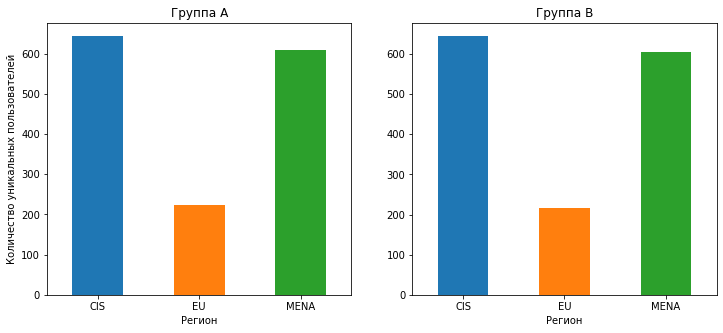

In [21]:
# Цвета, которые мы определили ранее
my_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Группа А 
(sessions_test_part[sessions_test_part['test_group'] == 'A']
 .groupby('region')['user_id'].nunique()
 .sort_index()
 .plot(kind='bar', ax=ax1, title='Группа A', color=my_colors, rot=0))

# Группа B 
(sessions_test_part[sessions_test_part['test_group'] == 'B']
 .groupby('region')['user_id'].nunique()
 .sort_index()
 .plot(kind='bar', ax=ax2, title='Группа B', color=my_colors, rot=0))

ax1.set_ylabel('Количество уникальных пользователей')
ax1.set_xlabel('Регион')
ax2.set_xlabel('Регион')

plt.show()

В обеих группах сохраняется практически идентичное распределение по регионам, с небольшими отличиями для регионов CIS и MENA.

#### 3.5. Вывод после проверки A/B-теста

Мониторинг подтвердил корректность проведения A/B-теста: разница в количестве пользователей между группами A и B составляет менее 1%, что свидетельствует о качественном сплитовании трафика. Выборки являются независимыми и не имеют пересечений, при этом в обеих группах сохраняется практически идентичное распределение по ключевым категориальным переменным — типам устройств и регионам. Учитывая однородность состава аудитории и отсутствие системных перекосов, можно сделать заключение, что эксперимент проходит без нарушений и полученные данные полностью пригодны для статистического анализа.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [22]:
sessions_test['good_session'] = sessions_test['page_counter'] >= 4
sessions_test

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,False
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,False
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,False
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,False
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,False
...,...,...,...,...,...,...,...,...,...,...,...,...
100000,CF77C27B238C1BE3,0F7BC9B33685377C,2025-10-22,2025-10-22 19:01:50,2025-10-20,3,0,3,MENA,Android,A,False
100001,D7ED66C581409AC2,26C4475005E70F47,2025-10-17,2025-10-17 22:12:38,2025-10-17,1,0,5,CIS,PC,A,True
100002,E7EA2D51238020C6,9B9CDE6A612CBD73,2025-10-24,2025-10-24 14:54:07,2025-10-14,2,0,3,MENA,PC,B,False
100003,8A6FEFD7F34C5DA1,37291EC27106EF9D,2025-10-18,2025-10-18 00:05:10,2025-10-14,3,0,4,EU,Android,B,True


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

Перед проведением эксперимента по внедрению нового алгоритма рекомендаций крайне важно формализовать гипотезы для нашего эксперимента. В качестве основной статистической проверки мы выдвигаем нулевую гипотезу о равенстве долей успешных первых сессий в обеих группах, предполагая, что $H_0: p_A = p_B$. Соответственно, альтернативная гипотеза $H_1: p_A < p_B$ будет указывать на наличие значимых изменений в вовлеченности пользователей после обновления алгоритма.

Помимо основной метрики, в анализ включается среднее суммарное время всех сессий на человека в день. Эта прокси-метрика выбрана потому, что она позволяет быстрее зафиксировать рост интереса к контенту, выступая опережающим индикатором для более инертных показателей. При этом критически важную роль играет барьерная метрика — количество уникальных пользователей в день (DAU). Отслеживание DAU необходимо для того, чтобы убедиться, что новые рекомендации не вызывают оттока аудитории из-за возможных технических сбоев или негативной реакции на изменения.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе.

In [23]:
results = sessions_test.groupby('test_group')['good_session'].mean()
print(results)
abs(results['A'] - results['B'])

test_group
A    0.307723
B    0.318290
Name: good_session, dtype: float64


0.010566571724179463

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведем на экран полученное значение p-value и свои выводы о статистической значимости.

In [24]:
successes = sessions_test.groupby('test_group')['good_session'].sum()
trials = sessions_test.groupby('test_group')['good_session'].count()
stat_ztest, p_value_ztest = proportions_ztest(
    [successes['A'], successes['B']], #m_a, m_b
    [trials['A'], trials['B']], #n_a, n_b
    alternative='smaller' # так как H_1: p_a < p_b
)
#Результаты
if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Отвергаем нулевую гипотезу') 

pvalue=0.0001574739988036123 < 0.05
Отвергаем нулевую гипотезу


#### 4.5. Вывод по результатам A/B-эксперимента

На основе анализа данных за период проведения A/B теста можно сделать вывод об успехе проведенного эксперимента по внедрению нового алгоритма рекомендаций. В ходе тестирования, охватившего всю активную аудиторию приложения, было зафиксировано положительное влияние изменений на ключевую метрику: доля успешных первых сессий в тестовой группе B увеличилась до 31.83% по сравнению с 30.77% в контрольной группе A. Полученное значение p-value составило 0.00016, что значительно ниже установленного уровня значимости 0.05, а это позволяет нам с высокой степенью надежности отклонить нулевую гипотезу и признать зафиксированный прирост в 1.06 процентных пункта статистически значимым. Учитывая, что было подтверждено статистически, что новый алгоритм помогает пользователям быстрее находить интересный контент и вовлекаться в продукт с первой сессии, можно порекомендовать команде разработки полноценное внедрение данного обновления для всех пользователей приложения.